In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
import scipy.stats as stats

SET-10 loaded in below cell

In [2]:
X = np.array([
    [1, 0.33073309],
    [2, 0.54369444],
    [3, 0.29529747],
    [4, 0.46559271],
    [5, -0.05695203],
    [6, 0.43069640],
    [7, 0.02009514],
    [8, 0.31847465],
    [9, 0.49351430],
    [10, 0.17981592],
    [11, 0.52438205],
    [12, 0.58500183],
    [13, 0.43767771],
    [14, 0.62868780],
    [15, 0.64497846],
    [16, 0.84301770],
    [17, 0.87863111],
    [18, 0.43254656],
    [19, 0.48892117],
    [20, 0.67881757],
    [21, 0.56631231],
    [22, 0.33996898],
    [23, 0.40246779],
    [24, 0.39762080],
    [25, 1.07677078],
    [26, 0.51395065],
    [27, 0.62430370],
    [28, 0.38322943],
    [29, 0.57588619],
    [30, 0.54417062],
    [31, 0.85865462],
    [32, 0.46821165],
    [33, 0.87412345],
    [34, 0.57517320],
    [35, 0.90470803],
    [36, 0.34487712],
    [37, 0.62729341],
    [38, 0.40126818],
    [39, 0.38110399],
    [40, 0.55132800],
    [41, 0.89883387],
    [42, 0.46158057],
    [43, 0.35415328],
    [44, 0.42464298],
    [45, 0.41388083],
    [46, 0.62306023],
    [47, 0.48552185],
    [48, 0.48740125],
    [49, 0.63067305],
    [50, 0.38109124],
    [51, 0.51753455],
    [52, 0.86756647],
    [53, 0.20092496],
    [54, 0.57621008],
    [55, 0.58526576]
])

print(X.shape)
print(X[:5])


(55, 2)
[[ 1.          0.33073309]
 [ 2.          0.54369444]
 [ 3.          0.29529747]
 [ 4.          0.46559271]
 [ 5.         -0.05695203]]


Model 3 trained and relevant statistics/plots given in output <BR>
Model 3 is my best-fit model <br>
Rest models given below

### **Model 3**
$$
y(t) = \beta_0 + \beta_1 t + \beta_2 t^2 + \beta_3 t^3 + \beta_4 t^4 + \epsilon(t)
$$


Estimated beta coefficients:
beta0 = 0.301192
beta1 = 0.000209
beta2 = 0.001812
beta3 = -0.000069
beta4 = 0.000001
SSE = 2.0096854015858603
MSE = 0.04019370803171721
R-squared (R²) = 0.192543

--- Estimate of σ² ---
SSE = 2.009685
Degrees of freedom (n - p) = 50
Estimated sigma² (σ²̂) = 4.019371e-02
Estimated sigma (σ̂) = 2.004837e-01

--- Confidence intervals for beta ---
beta_0: 0.301192  SE=1.513564e-01  95.0% CI = [-0.002816, 0.60520061]
beta_1: 0.000209  SE=3.673109e-02  95.0% CI = [-0.073568, 0.07398520]
beta_2: 0.001812  SE=2.633576e-03  95.0% CI = [-0.003478, 0.00710141]
beta_3: -0.000069  SE=7.035974e-05  95.0% CI = [-0.000211, 0.00007194]
beta_4: 0.000001  SE=6.234821e-07  95.0% CI = [-0.000001, 0.00000194]

--- Shapiro–Wilk Normality Test ---
Test statistic (W) = 0.983220
p-value = 0.635375
normality assumption holds


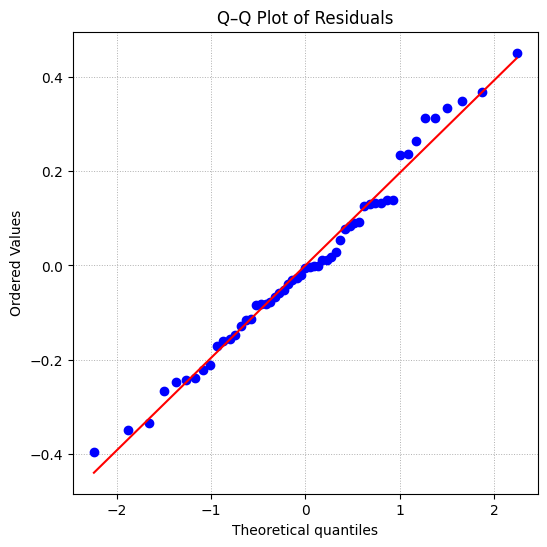

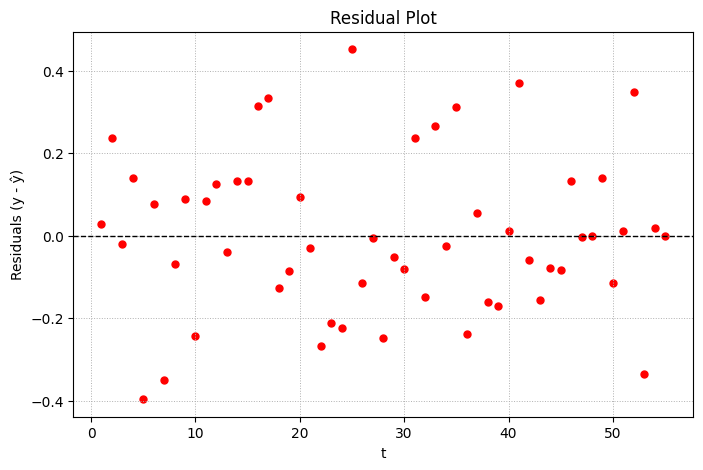

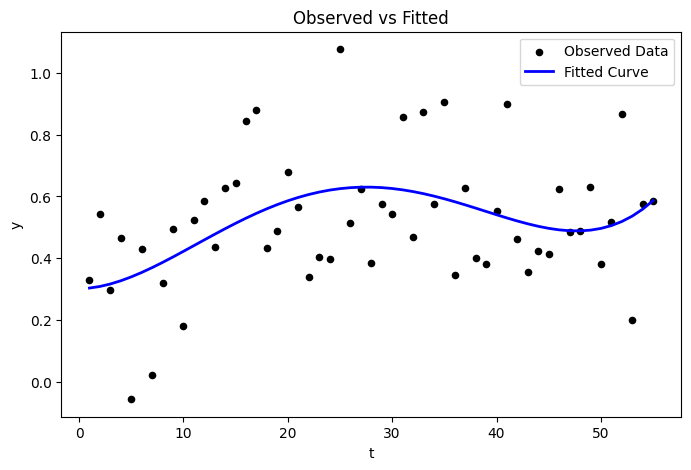

In [3]:
n=X.shape[0]
p=5 #5 parameters
t = X[:, 0]  
y = X[:, 1]   
X = np.column_stack([np.ones(n), t, t**2, t**3, t**4])

# Compute X^T X and X^T y
XtX = X.T @ X
Xty = X.T @ y
beta = np.linalg.inv(XtX) @ Xty

print("\nEstimated beta coefficients:")
for i, b in enumerate(beta):
    print(f"beta{i} = {b:.6f}")

# --------------------------
#Analysis using R^2 & SSE
# --------------------------

y_hat = X @ beta
residuals = y - y_hat
SSE = np.sum(residuals**2) #Sum of squared error
MSE = SSE / (n - p) #Mean Squared Error
SST = np.sum((y - np.mean(y))**2)      # Total Sum of Squares
SSR = SST - SSE   
R2 = 1 - (SSE / SST)
print(f"SSE = {SSE}")
print(f"MSE = {MSE}")
print(f"R-squared (R²) = {R2:.6f}")

# --------------------------
# Estimate of sigma^2
# --------------------------
df = n - p  # degrees of freedom
sigma2_hat = MSE  # same as SSE / (n - p)
sigma_hat = np.sqrt(sigma2_hat)

print("\n--- Estimate of σ² ---")
print(f"SSE = {SSE:.6f}")
print(f"Degrees of freedom (n - p) = {df}")
print(f"Estimated sigma² (σ²̂) = {sigma2_hat:.6e}")
print(f"Estimated sigma (σ̂) = {sigma_hat:.6e}")

# --------------------------
# Confidence Intervals
# --------------------------
# Covariance matrix of beta_hat = sigma^2 * (X^T X)^{-1}
cov_beta = np.linalg.inv(XtX)

#SE stands for standard error
se_beta = sigma_hat*np.sqrt(np.diag(cov_beta))

# t critical value and (1-alpha) CI 
alpha = 0.05
t_crit = stats.t.ppf(1-alpha/2, df)
ci_lower = beta - t_crit * se_beta
ci_upper = beta + t_crit * se_beta

print("\n--- Confidence intervals for beta ---")
for j in range(p):
    print(f"beta_{j}: {beta[j]:.6f}  SE={se_beta[j]:.6e}  "
          f"{100*(1-alpha):.1f}% CI = [{ci_lower[j]:.6f}, {ci_upper[j]:.8f}]")

# --------------------------
# Shapiro–Wilk Normality Test 
# --------------------------
stat, p_value = shapiro(residuals)

print("\n--- Shapiro–Wilk Normality Test ---")
print(f"Test statistic (W) = {stat:.6f}")
print(f"p-value = {p_value:.6f}")

# Interpretation
if p_value > 0.05:
    print("normality assumption holds")
else:
    print("normality assumption doesn't holds")

# --------------------------
# Q-Q Plot
# --------------------------
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()

# --------------------------
# Plot Residuals
# --------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, residuals, color="red", s=25)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residual Plot")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()

# --------------------------
# Plot Observed vs Fitted
# --------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, y, label="Observed Data", color="black", s=20)
plt.plot(t, y_hat, label="Fitted Curve", color="blue", linewidth=2)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Observed vs Fitted")
plt.legend()
plt.show()

### **Model 2**
$$
y(t) = \frac{\alpha_0 + \alpha_1 t}{\beta_0 + \beta_1 t} + \epsilon(t)
$$

iter  0: beta = [-1.00000000e+00 -2.93227606e-16], -Q = -1.487514e+01, ||grad|| = 5.190e+00
iter  1: beta = [-1.99940387e+00 -1.88139334e-05], -Q = -1.487519e+01, ||grad|| = 2.595e+00
iter  2: beta = [-3.99298598e+00 -2.11519676e-04], -Q = -1.487541e+01, ||grad|| = 1.297e+00
  backtracked 25 times, step -> 2.98e-08
iter  3: beta = [-3.99298610e+00 -2.11519661e-04], -Q = -1.487541e+01, ||grad|| = 1.297e+00
  backtracked 25 times, step -> 2.98e-08
iter  4: beta = [-3.99298622e+00 -2.11519663e-04], -Q = -1.487541e+01, ||grad|| = 1.297e+00
  backtracked 25 times, step -> 2.98e-08
iter  5: beta = [-3.99298634e+00 -2.11519645e-04], -Q = -1.487541e+01, ||grad|| = 1.297e+00
iter  6: beta = [-7.84405809e+00 -4.42564977e-03], -Q = -1.487804e+01, ||grad|| = 6.489e-01
  backtracked 25 times, step -> 2.98e-08
iter  7: beta = [-7.84405834e+00 -4.42564944e-03], -Q = -1.487804e+01, ||grad|| = 6.489e-01
iter  8: beta = [-14.97981632  -0.02880444], -Q = -1.488479e+01, ||grad|| = 3.242e-01
  backtracked 

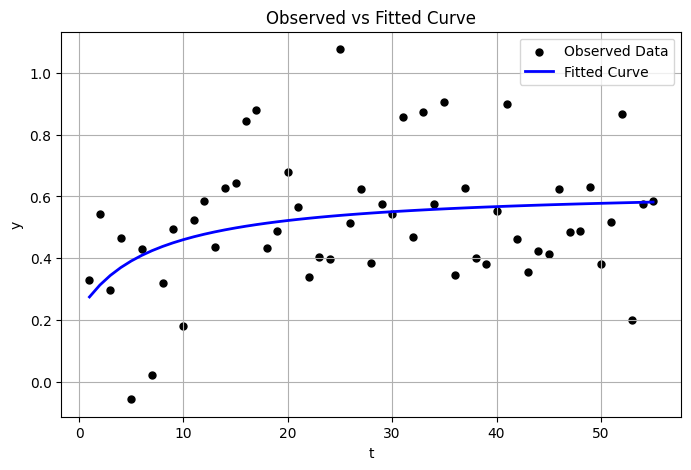

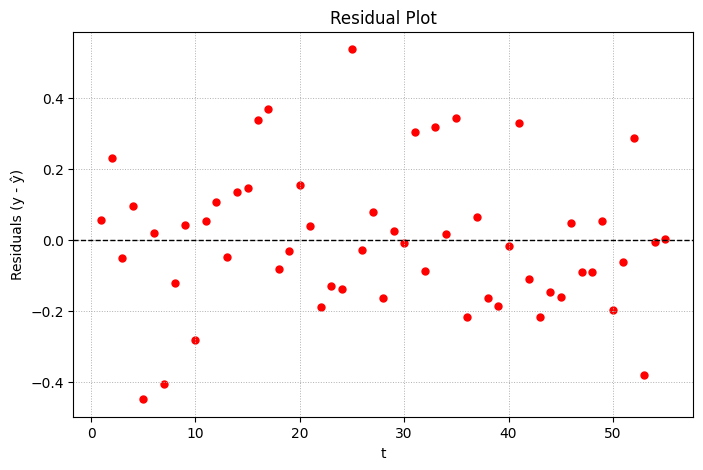

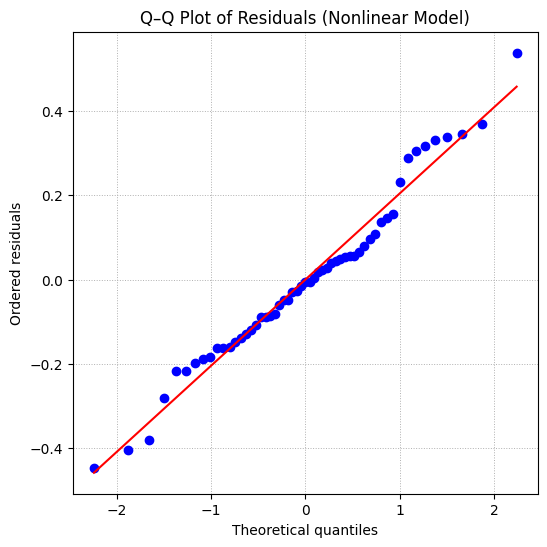

In [4]:
#Build X matrix
def X_matrix(beta0, beta1, t, eps=1e-12):
    denom = beta0 + beta1 * t
    denom = np.where(np.abs(denom) < eps, np.sign(denom) * eps + eps, denom) 
    X = np.column_stack([1.0 / denom, t / denom])
    return X

def alpha_and_XtXinv(beta0, beta1, t, y):
    X = X_matrix(beta0, beta1, t)
    XtX = X.T @ X              
    # Use pseudo-inverse for stability (works when XtX is ill-conditioned)
    XtX_inv = np.linalg.pinv(XtX)
    alpha_hat = XtX_inv @ (X.T @ y)
    return alpha_hat, XtX_inv, X

#Q using y^T X (X^T X)^{-1} X^T y
def Q_via_projection(beta):
    beta0, beta1 = beta
    alpha_hat, XtX_inv, X = alpha_and_XtXinv(beta0, beta1, t, y)
    # compute y^T X (X^T X)^{-1} X^T y  
    v = X.T @ y
    u = XtX_inv @ v
    Q = float(v.T @ u)
    return Q

#-------------------------------
#Newton Method on -Q
#-------------------------------
def grad(beta, eps=1e-6):
    """
    Returns a (2,1) column vector [d(-Q)/dβ0; d(-Q)/dβ1].
    """
    beta = np.asarray(beta, dtype=float)
    p = beta.size
    g = np.zeros(p, dtype=float)
    for j in range(p):
        e = np.zeros(p, dtype=float)
        e[j] = 1.0
        f_plus  = -Q_via_projection(beta + eps * e)
        f_minus = -Q_via_projection(beta - eps * e)
        g[j] = (f_plus - f_minus) / (2.0 * eps)
    return g.reshape(-1, 1) #column vector

import numpy as np

def hessian(beta, eps=1e-5):
    """
    Numerical Hessian of -Q(beta) using central differences.
    Returns a 2x2 numpy array.
    """
    beta = np.asarray(beta, dtype=float)
    p = beta.size
    H = np.zeros((p, p), dtype=float)
    
    # Loop over each pair of parameters (i, j)
    for i in range(p):
        for j in range(p):
            e_i = np.zeros(p); e_i[i] = 1.0
            e_j = np.zeros(p); e_j[j] = 1.0
            
            f_pp = -Q_via_projection(beta + eps*e_i + eps*e_j)
            f_pm = -Q_via_projection(beta + eps*e_i - eps*e_j)
            f_mp = -Q_via_projection(beta - eps*e_i + eps*e_j)
            f_mm = -Q_via_projection(beta - eps*e_i - eps*e_j)
            
            H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * eps**2)
    
    return H

def newton_iterate(beta0,
                   max_iter=50,
                   tol_grad=1e-8,
                   tol_step=1e-9,
                   grad_eps=1e-6,
                   hess_eps=1e-5,
                   damping=True,
                   max_backtracks=25,
                   verbose=True):
    
    beta = np.asarray(beta0, dtype=float).copy()
    history = {"beta": [], "Q": [], "grad_norm": [], "step_norm": []}

    # objective function to minimize (we minimize -Q)
    Qfunc = lambda b: -Q_via_projection(b)

    for k in range(max_iter):
        Qval = Qfunc(beta)
        g_col = grad(beta, eps=grad_eps)        
        g = g_col.ravel()                      
        gnorm = np.linalg.norm(g)

        if verbose:
            print(f"iter {k:2d}: beta = {beta}, -Q = {Qval:.6e}, ||grad|| = {gnorm:.3e}")

        # convergence on gradient norm
        if gnorm < tol_grad:
            if verbose:
                print("Stopping: gradient norm below tol.")
            break

        H = hessian(beta, eps=hess_eps)        

        # Solve H * delta = -g  => delta = - H^{-1} g
        try:
            delta = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            # Ill-conditioned Hessian -> use pseudo-inverse
            delta = -np.linalg.pinv(H) @ g

        step_norm = np.linalg.norm(delta)

        # If step is tiny, stop
        if step_norm < tol_step:
            if verbose:
                print("Stopping: step norm below tol.")
            break

        # Step Factor Modification
        step = 1.0
        beta_trial = beta + step * delta
        Q_trial = Qfunc(beta_trial)
        bt_count = 0
        if damping:
            while Q_trial > Qval and bt_count < max_backtracks:
                step *= 0.5
                beta_trial = beta + step * delta
                Q_trial = Qfunc(beta_trial)
                bt_count += 1
            if bt_count > 0 and verbose:
                print(f"  backtracked {bt_count} times, step -> {step:.2e}")

        # update
        beta = beta_trial

        # record history
        history["beta"].append(beta.copy())
        history["Q"].append(-Q_trial)       
        history["grad_norm"].append(gnorm)
        history["step_norm"].append(step_norm * step)

    return beta, history

beta0_guess = np.array([-1.00000000e+00 ,-2.93227606e-16])
beta_hat, hist = newton_iterate(beta0_guess,
                               max_iter=40,
                               tol_grad=1e-8,
                               tol_step=1e-9,
                               grad_eps=1e-6,
                               hess_eps=1e-5,
                               damping=True,
                               verbose=True)

print("\nEstimated beta coefficients:")
for i, a in enumerate(beta_hat):
    print(f"beta{i} = {a:.6f}")


alpha_hat, XtX_inv, X = alpha_and_XtXinv(beta_hat[0], beta_hat[1], t, y)
print("\nEstimated alpha coefficients (α̂):")
for i, a in enumerate(alpha_hat):
    print(f"alpha{i} = {a:.6f}")


# --- Parameters from Newton and alpha estimation ---
beta0, beta1 = beta_hat       # from Newton output
alpha0, alpha1 = alpha_hat    # from alpha_and_XtXinv()

# --- Predicted y values ---
y_hat = (alpha0 + alpha1 * t) / (beta0 + beta1 * t)

#-------------------------------
# --- Compute SSE and MSE ---
#-------------------------------
residuals = y - y_hat
SSE = np.sum(residuals**2)
SST = np.sum((y - np.mean(y))**2) 
SSR = SST - SSE 
R2 = 1 - (SSE / SST)
n = len(y)
p = 4   # parameters: alpha0, alpha1, beta0, beta1
MSE = SSE / (n - p)
sigma2_hat = MSE  # same as SSE / (n - p)
sigma_hat = np.sqrt(sigma2_hat)

print(f"SSE (Sum of Squared Errors): {SSE:.6f}")
print(f"MSE (Mean Squared Error):   {MSE:.6f}")
print(f"R-squared (R²) = {R2:.6f}")
print(f"Estimated sigma² (σ²̂) = {sigma2_hat:.6e}")
print(f"Estimated sigma (σ̂) = {sigma_hat:.6e}")

# --------------------------
# Confidence Intervals
# --------------------------
# Covariance matrix of beta_hat = sigma^2 * (X^T X)^{-1}
cov_beta = np.linalg.inv(XtX)

#SE stands for standard error
se_beta = sigma_hat*np.sqrt(np.diag(cov_beta))

# t critical value and (1-alpha) CI 
alpha = 0.05
t_crit = stats.t.ppf(1-alpha/2, df)
ci_lower = beta - t_crit * se_beta
ci_upper = beta + t_crit * se_beta

print("\n--- Confidence intervals for beta ---")
for j in range(p):
    print(f"beta_{j}: {beta[j]:.6f}  SE={se_beta[j]:.6e}  "
          f"{100*(1-alpha):.1f}% CI = [{ci_lower[j]:.6f}, {ci_upper[j]:.8f}]")
          
# --------------------------
# Shapiro–Wilk Normality Test 
# --------------------------
stat, p_value = shapiro(residuals)

print("\n--- Shapiro–Wilk Normality Test ---")
print(f"Test statistic (W) = {stat:.6f}")
print(f"p-value = {p_value:.6f}")

# Interpretation
if p_value > 0.05:
    print("normality assumption holds")
else:
    print("normality assumption doesn't holds")

#-------------------------------
# Plot Observed vs Fitted 
#-------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, y, label="Observed Data", color="black", s=25)
t_sorted_idx = np.argsort(t)
plt.plot(t[t_sorted_idx], y_hat[t_sorted_idx],
         label="Fitted Curve", color="blue", linewidth=2)

plt.xlabel("t")
plt.ylabel("y")
plt.title("Observed vs Fitted Curve")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------
# Plot Residuals
# --------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, residuals, color="red", s=25)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residual Plot")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()

# --------------------------
# Q–Q Plot of residuals (Nonlinear / Newton model)
# --------------------------
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals (Nonlinear Model)")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered residuals")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()


### **Model 1**
$$
y(t) = \alpha_0 + \alpha_1 e^{\beta_1 t} + \alpha_2 e^{\beta_2 t} + \epsilon(t)
$$

iter  0: beta = [-0.4 -0.1], -Q = -1.510850e+01, ||grad|| = 1.718e+00
iter  1: beta = [-0.86811775 -0.2658638 ], -Q = -1.511297e+01, ||grad|| = 7.159e-01
  backtracked 2 times, step -> 2.50e-01
iter  2: beta = [-0.8677305  -0.17974087], -Q = -1.515608e+01, ||grad|| = 1.991e-01
  backtracked 25 times, step -> 2.98e-08
iter  3: beta = [-0.86773052 -0.17974087], -Q = -1.515608e+01, ||grad|| = 1.991e-01
  backtracked 25 times, step -> 2.98e-08
iter  4: beta = [-0.86773053 -0.17974086], -Q = -1.515608e+01, ||grad|| = 1.991e-01
  backtracked 25 times, step -> 2.98e-08
iter  5: beta = [-0.86773055 -0.17974086], -Q = -1.515608e+01, ||grad|| = 1.991e-01
  backtracked 25 times, step -> 2.98e-08
iter  6: beta = [-0.86773056 -0.17974086], -Q = -1.515608e+01, ||grad|| = 1.991e-01
  backtracked 25 times, step -> 2.98e-08
iter  7: beta = [-0.86773058 -0.17974086], -Q = -1.515608e+01, ||grad|| = 1.991e-01
  backtracked 25 times, step -> 2.98e-08
iter  8: beta = [-0.86773059 -0.17974086], -Q = -1.51560

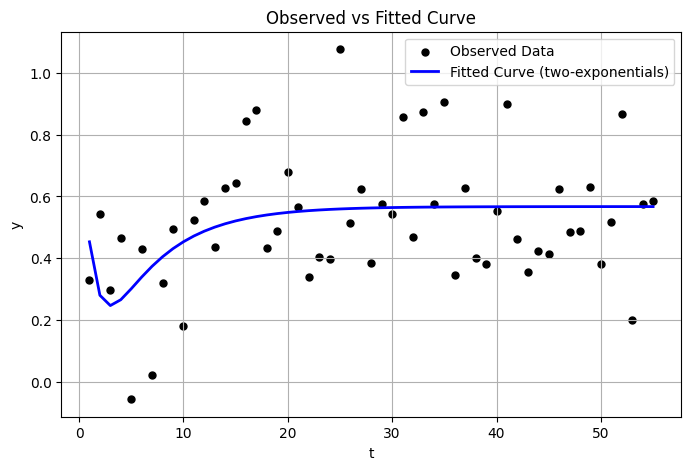

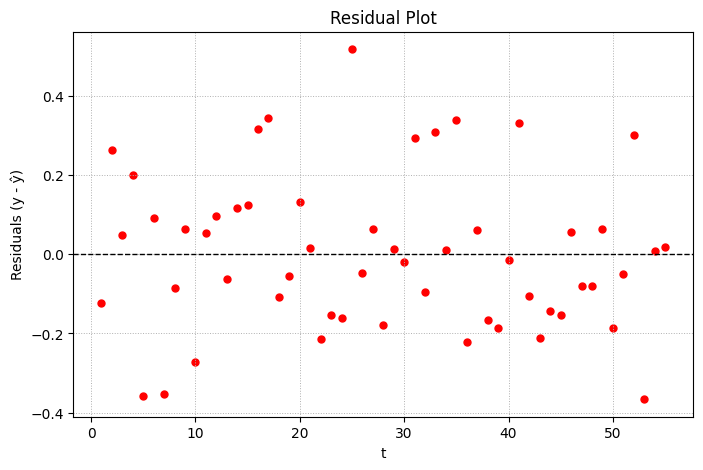

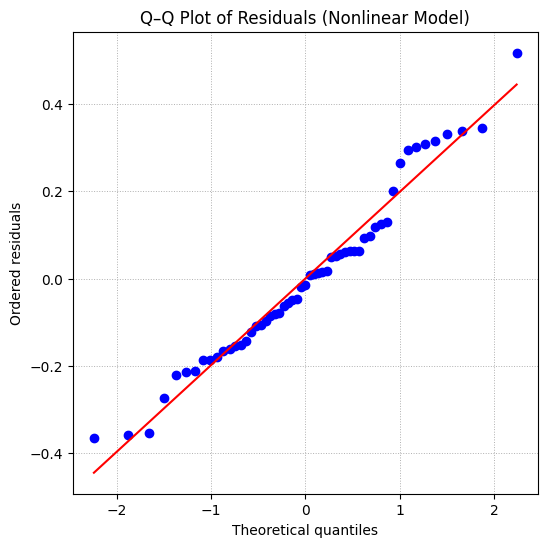

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Safe exponential to avoid overflow
def safe_exp(x, clip_min=-700, clip_max=700):
    return np.exp(np.clip(x, clip_min, clip_max))

# ---------------------------
# Build X matrix for the separable exponential model:
# columns = [1, exp(beta1 * t), exp(beta2 * t)]
def X_matrix(beta1, beta2, t):
    e1 = safe_exp(beta1 * t)
    e2 = safe_exp(beta2 * t)
    X = np.column_stack([np.ones_like(t), e1, e2])
    return X

def alpha_and_XtXinv(beta1, beta2, t, y):
    X = X_matrix(beta1, beta2, t)
    XtX = X.T @ X
    # Use pseudo-inverse for stability
    XtX_inv = np.linalg.pinv(XtX)
    alpha_hat = XtX_inv @ (X.T @ y)
    return alpha_hat, XtX_inv, X

# Q using y^T X (X^T X)^{-1} X^T y (scalar) - projection score for given betas
def Q_via_projection(beta):
    beta1, beta2 = beta
    alpha_hat, XtX_inv, X = alpha_and_XtXinv(beta1, beta2, t, y)
    v = X.T @ y
    u = XtX_inv @ v
    Q = float(v.T @ u)
    return Q

# -------------------------------
# Newton Method on -Q (unchanged numerics; uses central differences)
# -------------------------------
def grad(beta, eps=1e-6):
    beta = np.asarray(beta, dtype=float)
    p = beta.size
    g = np.zeros(p, dtype=float)
    for j in range(p):
        e = np.zeros(p, dtype=float)
        e[j] = 1.0
        f_plus  = -Q_via_projection(beta + eps * e)
        f_minus = -Q_via_projection(beta - eps * e)
        g[j] = (f_plus - f_minus) / (2.0 * eps)
    return g.reshape(-1, 1) # column vector

def hessian(beta, eps=1e-5):
    beta = np.asarray(beta, dtype=float)
    p = beta.size
    H = np.zeros((p, p), dtype=float)
    for i in range(p):
        for j in range(p):
            e_i = np.zeros(p); e_i[i] = 1.0
            e_j = np.zeros(p); e_j[j] = 1.0
            f_pp = -Q_via_projection(beta + eps*e_i + eps*e_j)
            f_pm = -Q_via_projection(beta + eps*e_i - eps*e_j)
            f_mp = -Q_via_projection(beta - eps*e_i + eps*e_j)
            f_mm = -Q_via_projection(beta - eps*e_i - eps*e_j)
            H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * eps**2)
    return H

def newton_iterate(beta0,
                   max_iter=50,
                   tol_grad=1e-8,
                   tol_step=1e-9,
                   grad_eps=1e-6,
                   hess_eps=1e-5,
                   damping=True,
                   max_backtracks=25,
                   verbose=True):
    beta = np.asarray(beta0, dtype=float).copy()
    history = {"beta": [], "Q": [], "grad_norm": [], "step_norm": []}
    Qfunc = lambda b: -Q_via_projection(b)   # we minimize -Q

    for k in range(max_iter):
        Qval = Qfunc(beta)
        g_col = grad(beta, eps=grad_eps)
        g = g_col.ravel()
        gnorm = np.linalg.norm(g)

        if verbose:
            print(f"iter {k:2d}: beta = {beta}, -Q = {Qval:.6e}, ||grad|| = {gnorm:.3e}")

        if gnorm < tol_grad:
            if verbose:
                print("Stopping: gradient norm below tol.")
            break

        H = hessian(beta, eps=hess_eps)

        try:
            delta = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            delta = -np.linalg.pinv(H) @ g

        step_norm = np.linalg.norm(delta)
        if step_norm < tol_step:
            if verbose:
                print("Stopping: step norm below tol.")
            break

        # Step Factor / backtracking (same logic you had)
        step = 1.0
        beta_trial = beta + step * delta
        Q_trial = Qfunc(beta_trial)
        bt_count = 0
        if damping:
            while Q_trial > Qval and bt_count < max_backtracks:
                step *= 0.5
                beta_trial = beta + step * delta
                Q_trial = Qfunc(beta_trial)
                bt_count += 1
            if bt_count > 0 and verbose:
                print(f"  backtracked {bt_count} times, step -> {step:.2e}")

        beta = beta_trial
        history["beta"].append(beta.copy())
        history["Q"].append(-Q_trial)
        history["grad_norm"].append(gnorm)
        history["step_norm"].append(step_norm * step)

    return beta, history

# ---------------------------

beta0_guess = np.array([-0.4, -0.1])   # [beta1, beta2] initial guess

# Run Newton on -Q (outer optimization over betas)
beta_hat, hist = newton_iterate(beta0_guess,
                               max_iter=40,
                               tol_grad=1e-8,
                               tol_step=1e-9,
                               grad_eps=1e-6,
                               hess_eps=1e-5,
                               damping=True,
                               verbose=True)
print("\nEstimated beta coefficients:")
for i, a in enumerate(beta_hat):
    print(f"beta{i} = {a:.6f}")

# Given beta_hat, compute alpha_hat by linear solve (projection)
alpha_hat, XtX_inv, X = alpha_and_XtXinv(beta_hat[0], beta_hat[1], t, y)
print("\nEstimated alpha coefficients (α̂):")
for i, a in enumerate(alpha_hat):
    print(f"alpha{i} = {a:.6f}")

# --- Predicted y values for exponential model ---
alpha0, alpha1, alpha2 = alpha_hat
beta1, beta2 = beta_hat
y_hat = alpha0 + alpha1 * safe_exp(beta1 * t) + alpha2 * safe_exp(beta2 * t)

# --------------------------
# Compute SSE and MSE and R2 
# --------------------------
residuals = y - y_hat
SSE = np.sum(residuals**2)
n = len(y)
p = 5   # parameters: alpha0, alpha1, alpha2, beta1, beta2
MSE = SSE / max(1, (n - p))
SST = np.sum((y - np.mean(y))**2) 
SSR = SST - SSE 
R2 = 1 - (SSE / SST)
sigma2_hat = MSE  # same as SSE / (n - p)
sigma_hat = np.sqrt(sigma2_hat)

print(f"SSE (Sum of Squared Errors): {SSE:.6f}")
print(f"MSE (Mean Squared Error):   {MSE:.6f}")
print(f"R2 Score: {R2:.6f}")
print(f"Estimated sigma² (σ²̂) = {sigma2_hat:.6e}")
print(f"Estimated sigma (σ̂) = {sigma_hat:.6e}")

# --------------------------
# Confidence Intervals
# --------------------------
# Covariance matrix of beta_hat = sigma^2 * (X^T X)^{-1}
cov_beta = np.linalg.inv(XtX)

#SE stands for standard error
se_beta = sigma_hat*np.sqrt(np.diag(cov_beta))

# t critical value and (1-alpha) CI 
alpha = 0.05
t_crit = stats.t.ppf(1-alpha/2, df)
ci_lower = beta - t_crit * se_beta
ci_upper = beta + t_crit * se_beta

print("\n--- Confidence intervals for beta ---")
for j in range(p):
    print(f"beta_{j}: {beta[j]:.6f}  SE={se_beta[j]:.6e}  "
          f"{100*(1-alpha):.1f}% CI = [{ci_lower[j]:.6f}, {ci_upper[j]:.8f}]")
    
# --------------------------
# Shapiro–Wilk Normality Test 
# --------------------------
stat, p_value = shapiro(residuals)

print("\n--- Shapiro–Wilk Normality Test ---")
print(f"Test statistic (W) = {stat:.6f}")
print(f"p-value = {p_value:.6f}")

# Interpretation
if p_value > 0.05:
    print("normality assumption holds")
else:
    print("normality assumption doesn't holds")

# --------------------------
# Plot Observed vs Fitted 
# --------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, y, label="Observed Data", color="black", s=25)
t_sorted_idx = np.argsort(t)
plt.plot(t[t_sorted_idx], y_hat[t_sorted_idx],
         label="Fitted Curve (two-exponentials)", color="blue", linewidth=2)

plt.xlabel("t")
plt.ylabel("y")
plt.title("Observed vs Fitted Curve")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# Plot Residuals
# --------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, residuals, color="red", s=25)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residual Plot")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()

# --------------------------
# Q–Q Plot of residuals (Nonlinear / Newton model)
# --------------------------
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals (Nonlinear Model)")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered residuals")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.show()
